# Rooms fill. Plans change.
### Seasonal Patterns & Cancellation Analysis — rebuilt around reservation pressure

The useful question is not only **when bookings peak**. It is **which part of that demand is fragile, how early the risk enters the system, and where revenue exposure accumulates**.

This notebook uses the **INN Hotels / Hotel Reservations** dataset (36,275 reservations, 19 columns) instead of the Hotel Booking Demand dataset named in the original Week 3 brief, because that original dataset had already been used in an earlier task. The replacement dataset does not contain `hotel` or `country`; those requirements are therefore translated to the closest real fields rather than fabricated.


## Brief translation — before touching the data

| Original brief | What exists in this dataset | Implementation here |
|---|---|---|
| Month × hotel booking pivot | `arrival_month` + `room_type_reserved` | Month × room-type pivot + heatmap |
| Monthly cancellation rate per hotel | no `hotel` field | monthly overall rate + month × room-type cancellation heatmap |
| Lead time: canceled vs not | `lead_time`, `booking_status` | summary + distribution comparison |
| Market-segment breakdown | `market_segment_type` | bookings, cancellations, rate, lead time |
| Top countries | no `country` field | replaced by room-type exposure; omission is documented, not hidden |
| ADR by month/hotel type | `avg_price_per_room` | price-rate analogue; dual-axis view for dominant room type |
| Lowest-cancellation segment | available | calculated directly |
| 4 revenue-management insights | available | decision matrix at the end |

The country/hotel substitutions are analytical adaptations, not column renames.


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# your current local folder is checked first; same-folder CSV remains a fallback
candidates = [
    Path(r"C:\Users\anarrasulzada\Desktop\archive (13)\Hotel Reservations.csv"),
    Path("Hotel Reservations.csv")
]

data_path = next((p for p in candidates if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Hotel Reservations.csv was not found in the local archive folder or next to the notebook.")

visual_dir = Path("visuals")
visual_dir.mkdir(exist_ok=True)

df = pd.read_csv(data_path)
df.shape

(36275, 19)

## Data reality check — what can safely be analyzed?

In [2]:
audit = pd.Series({
    "rows": len(df),
    "columns": df.shape[1],
    "missing_values": int(df.isna().sum().sum()),
    "duplicate_rows": int(df.duplicated().sum()),
    "unique_booking_ids": int(df["Booking_ID"].nunique())
}, name="value")

audit.to_frame()

,value
rows,36275
columns,19
missing_values,0
duplicate_rows,0
unique_booking_ids,36275


In [3]:
# the original day field is kept, then year/month/day are combined into a real date
df = df.rename(columns={"arrival_date": "arrival_day"})

df["arrival_date"] = pd.to_datetime(
    {
        "year": df["arrival_year"],
        "month": df["arrival_month"],
        "day": df["arrival_day"]
    },
    errors="coerce"
)

invalid_calendar_rows = df.loc[
    df["arrival_date"].isna(),
    ["arrival_year", "arrival_month", "arrival_day"]
].value_counts()

invalid_calendar_rows

arrival_year  arrival_month  arrival_day
2018          2              29             37
Name: count, dtype: int64

There are **37 records marked 2018-02-29**. They become `NaT` because that calendar date does not exist. They are not deleted: the analysis is monthly and the original year/month fields remain valid for that purpose.

There are no `country`, `agent`, `company` or `hotel` columns in this replacement dataset, so the original missing-value instructions for those fields do not apply.

In [4]:
df["is_canceled"] = (df["booking_status"] == "Canceled").astype(int)

month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
month_map = {i + 1: month for i, month in enumerate(month_order)}

df["month"] = df["arrival_month"].map(month_map)
df["month"] = pd.Categorical(df["month"], categories=month_order, ordered=True)

df["stay_nights"] = df["no_of_weekend_nights"] + df["no_of_week_nights"]
df["booking_value_proxy"] = df["avg_price_per_room"] * df["stay_nights"]

round(df["is_canceled"].mean() * 100, 2)

np.float64(32.76)

## Where does demand actually concentrate?

In [5]:
room_month_pivot = pd.pivot_table(
    df,
    index="month",
    columns="room_type_reserved",
    values="Booking_ID",
    aggfunc="count",
    fill_value=0,
    observed=False
).reindex(month_order)

room_month_pivot

room_type_reserved,Room_Type 1,Room_Type 2,Room_Type 3,Room_Type 4,Room_Type 5,Room_Type 6,Room_Type 7
month,,,,,,,
Jan,864,50,0,82,3,12,3
Feb,1384,51,0,211,20,33,5
Mar,1807,64,0,420,12,48,7
Apr,1998,44,0,578,15,93,8
May,1883,24,0,572,22,82,15
Jun,2596,36,1,494,15,52,9
Jul,2127,72,0,585,27,88,21
Aug,2830,100,0,658,27,172,26
Sep,3630,52,0,736,51,124,18


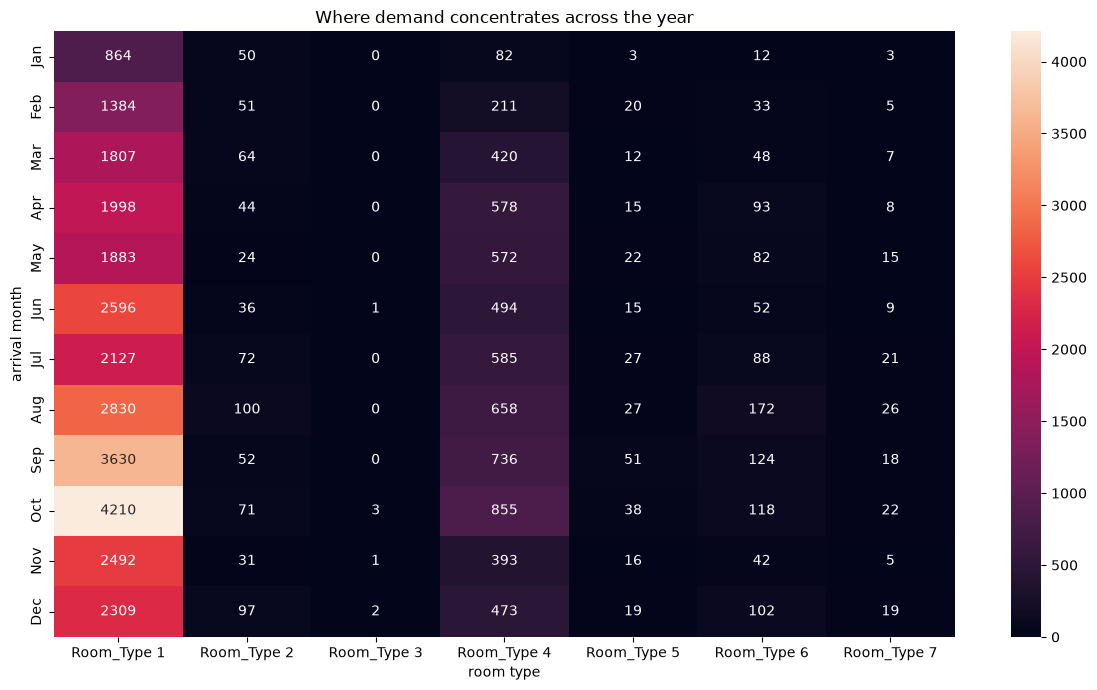

In [6]:
plt.figure(figsize=(12, 7))
sns.heatmap(room_month_pivot, annot=True, fmt="g")
plt.title("Where demand concentrates across the year")
plt.xlabel("room type")
plt.ylabel("arrival month")
plt.tight_layout()
plt.savefig(visual_dir / "01 seasonal demand heatmap.png", dpi=180, bbox_inches="tight")
plt.show()

October is the volume peak with **5,317 reservations**. The mix is highly concentrated: `Room_Type 1` alone contributes **4,210 October bookings** and **77.5% of all bookings** across the dataset. A seasonal decision therefore affects one room class much more than the others.

## Does peak demand also mean peak cancellation risk?

In [7]:
monthly_summary = (
    df.groupby("month", observed=False)
      .agg(
          bookings=("Booking_ID", "size"),
          cancellations=("is_canceled", "sum"),
          cancellation_rate=("is_canceled", "mean")
      )
      .reindex(month_order)
)
monthly_summary["cancellation_rate"] *= 100
monthly_summary.round(2)

,bookings,cancellations,cancellation_rate
month,,,
Jan,1014,24,2.37
Feb,1704,430,25.23
Mar,2358,700,29.69
Apr,2736,995,36.37
May,2598,948,36.49
Jun,3203,1291,40.31
Jul,2920,1314,45.00
Aug,3813,1488,39.02
Sep,4611,1538,33.36


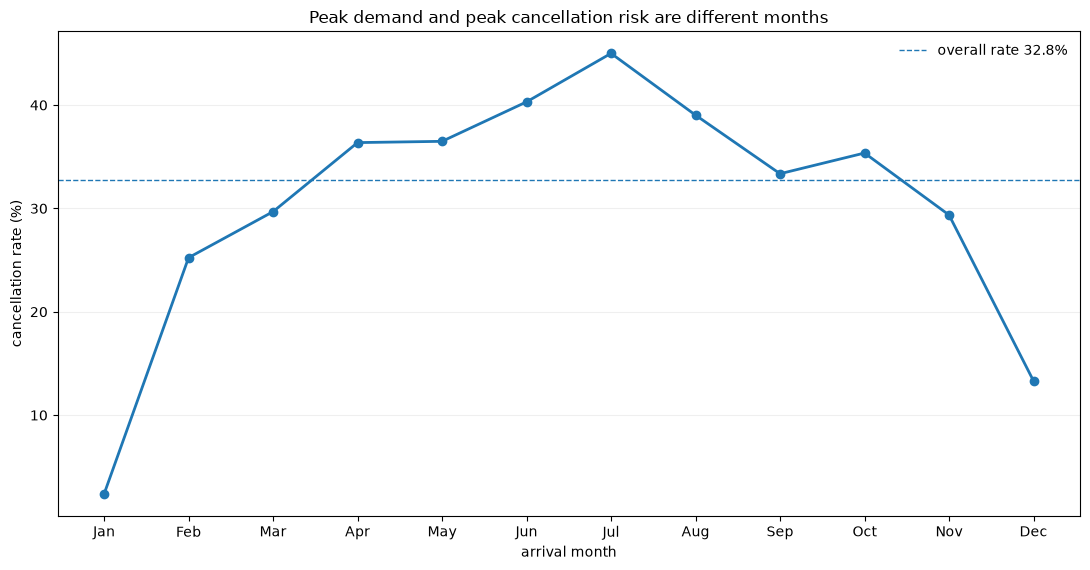

In [8]:
overall_rate = df["is_canceled"].mean() * 100

plt.figure(figsize=(11, 5.8))
plt.plot(month_order, monthly_summary["cancellation_rate"], marker="o", linewidth=2)
plt.axhline(overall_rate, linestyle="--", linewidth=1, label=f"overall rate {overall_rate:.1f}%")
plt.title("Peak demand and peak cancellation risk are different months")
plt.xlabel("arrival month")
plt.ylabel("cancellation rate (%)")
plt.legend(frameon=False)
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig(visual_dir / "02 monthly cancellation pressure.png", dpi=180, bbox_inches="tight")
plt.show()

The two peaks are different: **October** has the most bookings, while **July** has the highest cancellation rate at **45.0%**. January is only **2.4%**. Capacity planning and cancellation-risk controls should therefore not be driven by the same monthly ranking.

## Is cancellation pressure uniform across room types?

In [9]:
room_cancel_pivot = pd.pivot_table(
    df,
    index="month",
    columns="room_type_reserved",
    values="is_canceled",
    aggfunc="mean",
    observed=False
).reindex(month_order) * 100

room_cancel_pivot.round(1)

room_type_reserved,Room_Type 1,Room_Type 2,Room_Type 3,Room_Type 4,Room_Type 5,Room_Type 6,Room_Type 7
month,,,,,,,
Jan,2.0,10.0,NaN,2.4,0.0,0.0,0.0
Feb,25.6,35.3,NaN,21.3,15.0,30.3,0.0
Mar,28.3,39.1,NaN,32.6,16.7,50.0,14.3
Apr,36.1,18.2,NaN,36.7,26.7,50.5,37.5
May,36.6,54.2,NaN,33.9,4.5,57.3,26.7
Jun,40.1,25.0,100.0,41.7,53.3,48.1,22.2
Jul,45.6,65.3,NaN,40.3,14.8,56.8,38.1
Aug,36.5,45.0,NaN,48.5,33.3,41.9,34.6
Sep,32.9,42.3,NaN,35.1,29.4,37.9,16.7


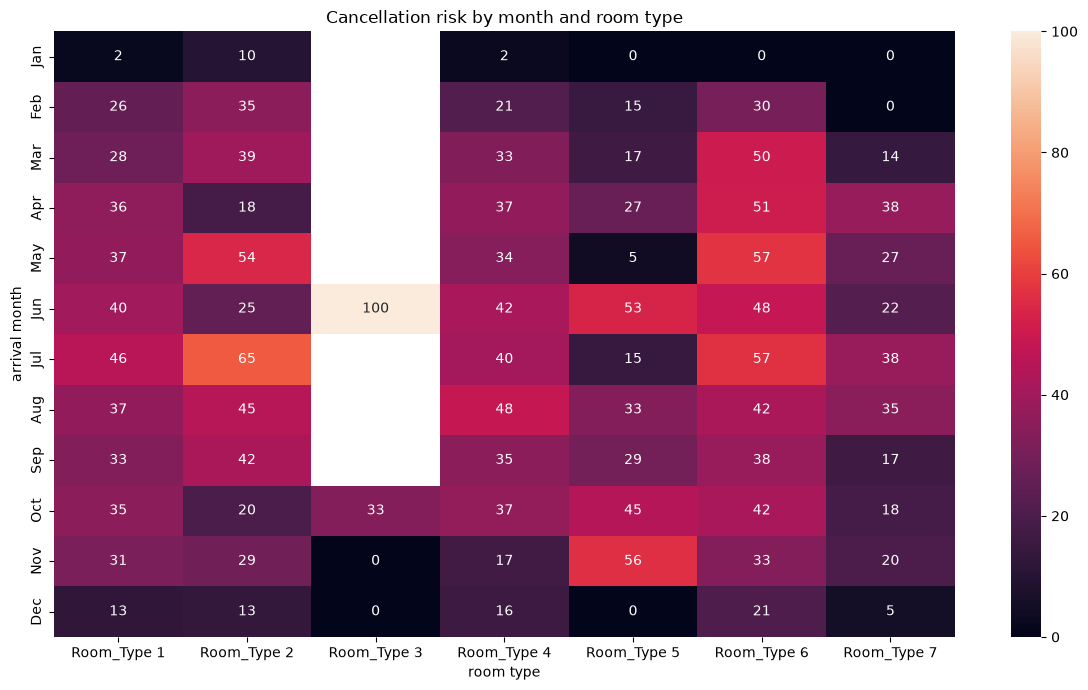

In [10]:
plt.figure(figsize=(12, 7))
sns.heatmap(room_cancel_pivot, annot=True, fmt=".0f")
plt.title("Cancellation risk by month and room type")
plt.xlabel("room type")
plt.ylabel("arrival month")
plt.tight_layout()
plt.savefig(visual_dir / "03 room cancellation heatmap.png", dpi=180, bbox_inches="tight")
plt.show()

This is the dataset-equivalent of the original **monthly cancellation rate per hotel** requirement. The heatmap makes two things visible at once: season and room mix. `Room_Type 6` is especially fragile overall (**42.0% cancellation**), while some small-volume room/month cells are volatile because their denominators are tiny.

## How early do fragile bookings enter the system?

In [11]:
lead_summary = (
    df.groupby("booking_status")["lead_time"]
      .agg(["count", "mean", "median"])
      .reindex(["Not_Canceled", "Canceled"])
)
lead_summary.round(2)

,count,mean,median
booking_status,,,
Not_Canceled,24390,58.93,39.0
Canceled,11885,139.22,122.0


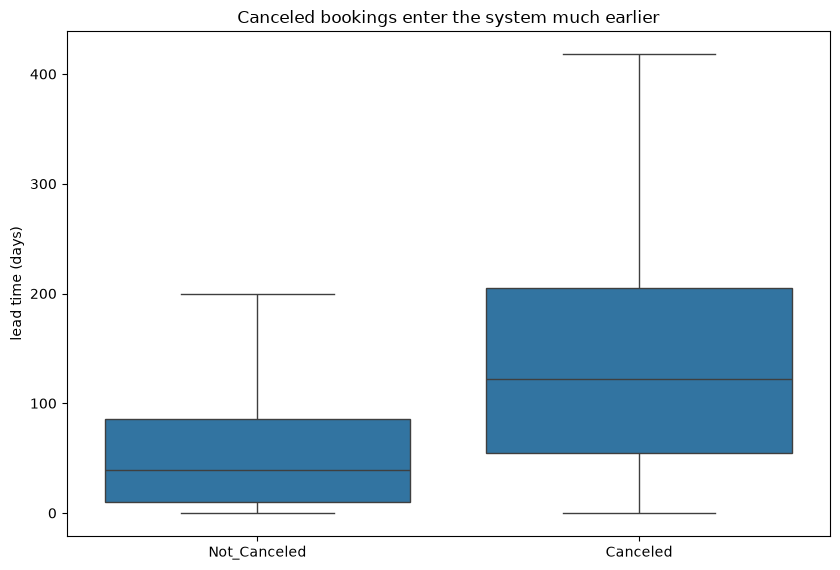

In [12]:
plt.figure(figsize=(8.5, 5.8))
sns.boxplot(
    data=df,
    x="booking_status",
    y="lead_time",
    order=["Not_Canceled", "Canceled"],
    showfliers=False
)
plt.title("Canceled bookings enter the system much earlier")
plt.xlabel("")
plt.ylabel("lead time (days)")
plt.tight_layout()
plt.savefig(visual_dir / "04 lead time distribution.png", dpi=180, bbox_inches="tight")
plt.show()

Canceled reservations are booked **139.2 days ahead on average**, versus **58.9 days** for kept reservations. The medians tell the same story: **122 days vs 39 days**. Lead time is not just scheduling information; it is a risk window.

## Risk increasing ...

In [13]:
lead_bins = [-1, 7, 30, 90, 180, float("inf")]
lead_labels = ["0–7", "8–30", "31–90", "91–180", "181+"]

df["lead_band"] = pd.cut(df["lead_time"], bins=lead_bins, labels=lead_labels)

lead_risk = (
    df.groupby("lead_band", observed=False)
      .agg(bookings=("Booking_ID", "size"), cancellations=("is_canceled", "sum"), cancellation_rate=("is_canceled", "mean"))
)
lead_risk["cancellation_rate"] *= 100
lead_risk.round(2)

,bookings,cancellations,cancellation_rate
lead_band,,,
0–7,5801,514,8.86
8–30,6610,1249,18.90
31–90,10815,2733,25.27
91–180,7772,3490,44.90
181+,5277,3899,73.89


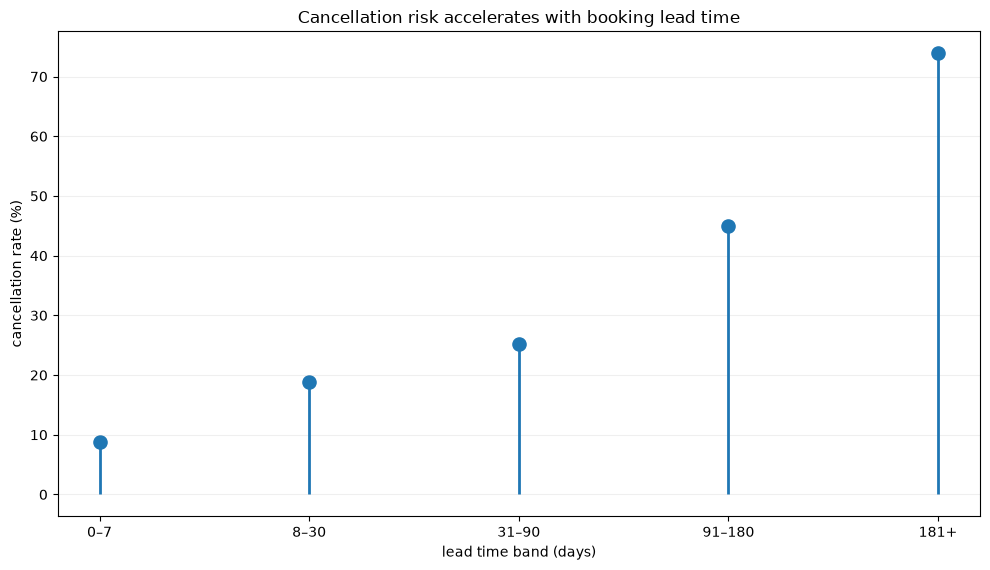

In [14]:
x = range(len(lead_risk))
plt.figure(figsize=(10, 5.8))
plt.vlines(x, 0, lead_risk["cancellation_rate"], linewidth=2)
plt.scatter(x, lead_risk["cancellation_rate"], s=90)
plt.xticks(list(x), lead_risk.index)
plt.title("Cancellation risk accelerates with booking lead time")
plt.xlabel("lead time band (days)")
plt.ylabel("cancellation rate (%)")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig(visual_dir / "05 lead time risk curve.png", dpi=180, bbox_inches="tight")
plt.show()

The relationship is not subtle: cancellation rises from **8.9%** inside 7 days to **73.9%** beyond 180 days. The 91–180 day band is already at **44.9%**. That creates a practical trigger for reconfirmation or differentiated cancellation terms.

## Which acquisition segments combine scale with risk?

In [15]:
segment_summary = (
    df.groupby("market_segment_type")
      .agg(
          bookings=("Booking_ID", "size"),
          cancellations=("is_canceled", "sum"),
          cancellation_rate=("is_canceled", "mean"),
          avg_lead_time=("lead_time", "mean"),
          avg_price_per_room=("avg_price_per_room", "mean")
      )
      .sort_values("bookings", ascending=False)
)
segment_summary["cancellation_rate"] *= 100
segment_summary.round(2)

,bookings,cancellations,cancellation_rate,avg_lead_time,avg_price_per_room
market_segment_type,,,,,
Online,23214,8475,36.51,75.33,112.26
Offline,10528,3153,29.95,122.87,91.63
Corporate,2017,220,10.91,21.82,82.91
Complementary,391,0,0.00,12.04,3.14
Aviation,125,37,29.60,5.49,100.70


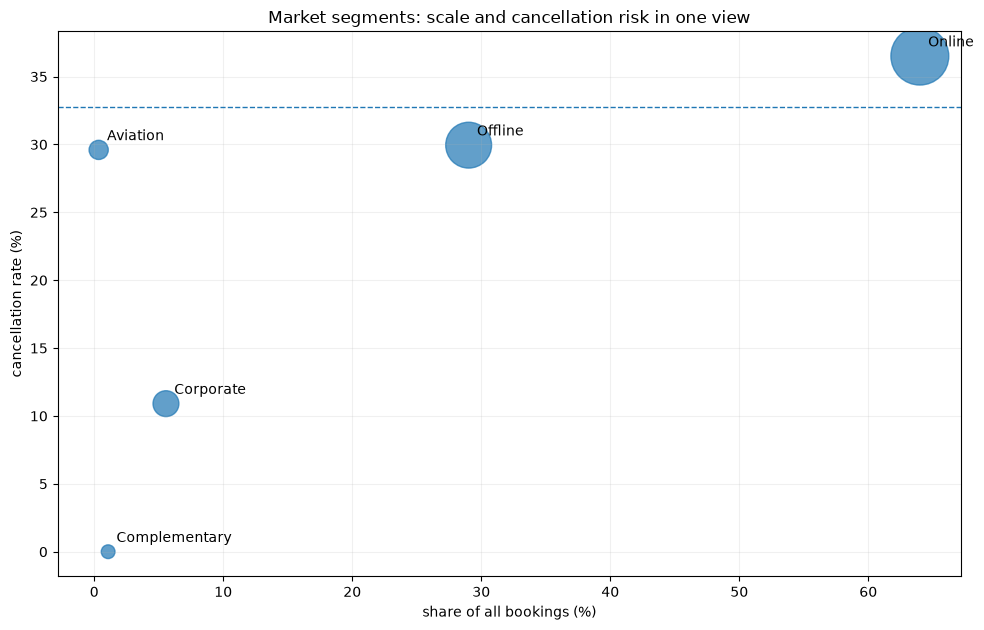

In [16]:
segment_plot = segment_summary.copy()
segment_plot["booking_share"] = segment_plot["bookings"] / len(df) * 100
point_size = (segment_plot["cancellations"] + 1).pow(0.5) * 18 + 80

plt.figure(figsize=(10, 6.4))
plt.scatter(
    segment_plot["booking_share"],
    segment_plot["cancellation_rate"],
    s=point_size,
    alpha=0.7
)
plt.axhline(df["is_canceled"].mean() * 100, linestyle="--", linewidth=1)

for name, row in segment_plot.iterrows():
    plt.annotate(name, (row["booking_share"], row["cancellation_rate"]), xytext=(6, 7), textcoords="offset points")

plt.title("Market segments: scale and cancellation risk in one view")
plt.xlabel("share of all bookings (%)")
plt.ylabel("cancellation rate (%)")
plt.grid(alpha=0.18)
plt.tight_layout()
plt.savefig(visual_dir / "06 market segment risk map.png", dpi=180, bbox_inches="tight")
plt.show()

In [17]:
lowest_risk_segment = segment_summary["cancellation_rate"].idxmin()
lowest_risk_rate = segment_summary.loc[lowest_risk_segment, "cancellation_rate"]

lowest_risk_segment, round(lowest_risk_rate, 2)

('Complementary', np.float64(0.0))

`Complementary` is the lowest-cancellation segment at **0%**, satisfying the bonus check, but it contains only **391 bookings**. The commercially important problem is `Online`: **23,214 bookings**, **8,475 cancellations**, and a **36.5% cancellation rate**.

## If rate is not enough, where does booking value disappear?

In [18]:
value_at_risk = (
    df.loc[df["is_canceled"].eq(1)]
      .groupby("market_segment_type")["booking_value_proxy"]
      .sum()
      .sort_values(ascending=False)
)

value_at_risk.round(2)

market_segment_type
Online       3318253.94
Offline       894593.97
Corporate      58062.16
Aviation       25264.00
Name: booking_value_proxy, dtype: float64

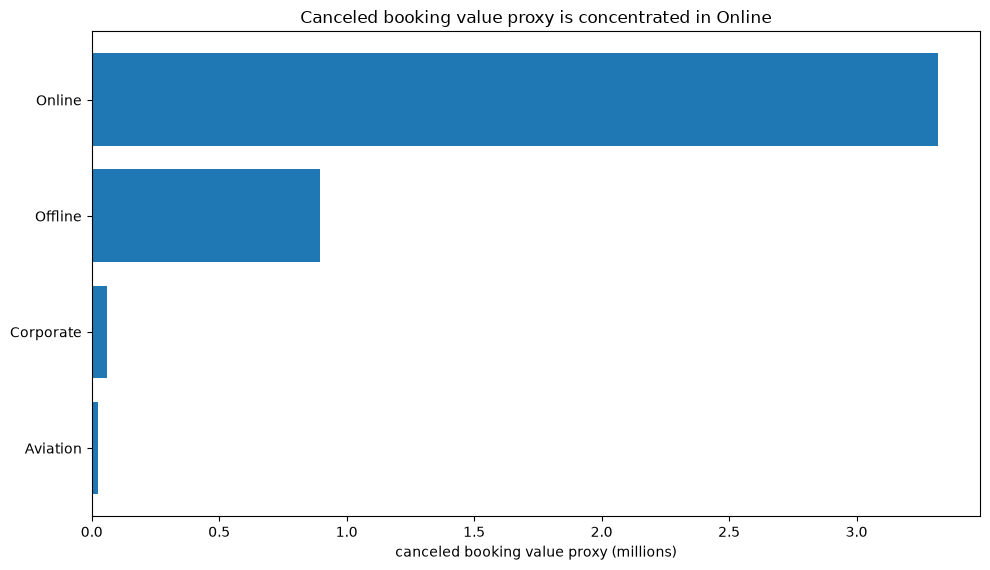

In [19]:
plot_value = value_at_risk.sort_values() / 1_000_000
plt.figure(figsize=(10, 5.8))
plt.barh(plot_value.index, plot_value.values)
plt.title("Canceled booking value proxy is concentrated in Online")
plt.xlabel("canceled booking value proxy (millions)")
plt.tight_layout()
plt.savefig(visual_dir / "07 cancellation value at risk.png", dpi=180, bbox_inches="tight")
plt.show()

This is a **proxy**, not audited revenue: `avg_price_per_room × stay_nights` for canceled bookings. It estimates roughly **3.32M** of canceled booking value in the Online segment versus **0.89M** Offline. The purpose is prioritization, not accounting.

## Does the price signal move with demand?

In [20]:
room_volume = df["room_type_reserved"].value_counts()
focus_room = room_volume.idxmax()

focus_monthly = (
    df.loc[df["room_type_reserved"].eq(focus_room)]
      .groupby("month", observed=False)
      .agg(bookings=("Booking_ID", "size"), avg_price_per_room=("avg_price_per_room", "mean"))
      .reindex(month_order)
)

focus_room, focus_monthly.round(2)

('Room_Type 1',
        bookings  avg_price_per_room
 month                              
 Jan         864               73.85
 Feb        1384               76.00
 Mar        1807               85.60
 Apr        1998               92.90
 May        1883              103.25
 Jun        2596              106.36
 Jul        2127              101.14
 Aug        2830              103.12
 Sep        3630              107.72
 Oct        4210               97.92
 Nov        2492               88.65
 Dec        2309               81.10)

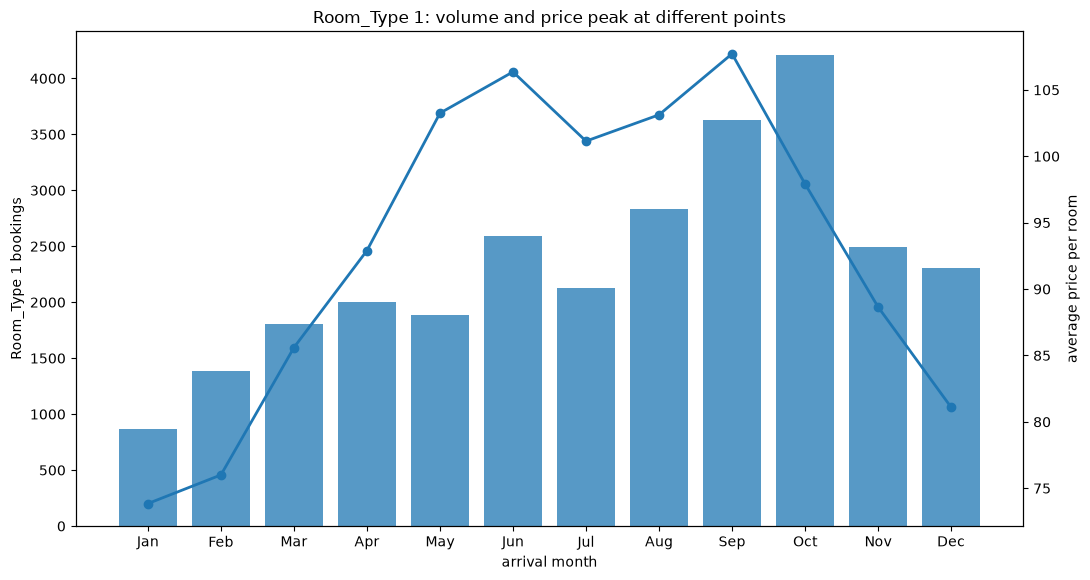

In [21]:
fig, ax1 = plt.subplots(figsize=(11, 5.9))
ax1.bar(month_order, focus_monthly["bookings"], alpha=0.75)
ax1.set_xlabel("arrival month")
ax1.set_ylabel(f"{focus_room} bookings")
ax1.set_title(f"{focus_room}: volume and price peak at different points")

ax2 = ax1.twinx()
ax2.plot(month_order, focus_monthly["avg_price_per_room"], marker="o", linewidth=2)
ax2.set_ylabel("average price per room")

fig.tight_layout()
fig.savefig(visual_dir / "08 room type 1 demand and price.png", dpi=180, bbox_inches="tight")
plt.show()

This completes the bonus price comparison using `avg_price_per_room`, the closest available rate measure to ADR. For the dominant `Room_Type 1`, average price peaks in **September (~107.72)** while booking volume peaks in **October (4,210)**. A single “peak season” rule would miss that timing difference.

## Is previous guest behavior a useful stability signal?

In [22]:
repeat_summary = (
    df.groupby("repeated_guest")
      .agg(bookings=("Booking_ID", "size"), cancellations=("is_canceled", "sum"), cancellation_rate=("is_canceled", "mean"))
)
repeat_summary["cancellation_rate"] *= 100
repeat_summary.index = ["New / non-repeat", "Repeat guest"]
repeat_summary.round(2)

,bookings,cancellations,cancellation_rate
New / non-repeat,35345,11869,33.58
Repeat guest,930,16,1.72


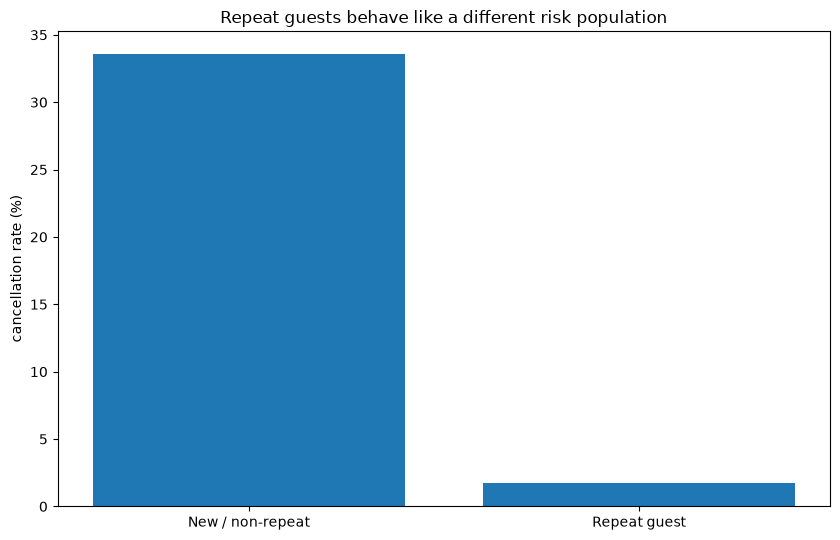

In [23]:
plt.figure(figsize=(8.5, 5.5))
plt.bar(repeat_summary.index, repeat_summary["cancellation_rate"])
plt.title("Repeat guests behave like a different risk population")
plt.ylabel("cancellation rate (%)")
plt.tight_layout()
plt.savefig(visual_dir / "09 repeat guest reliability.png", dpi=180, bbox_inches="tight")
plt.show()

Only **1.7%** of repeat-guest bookings are canceled, compared with **33.6%** for non-repeat bookings. Repeat status should not replace a full risk model, but it is a strong operational segmentation signal in this dataset.

## Decision matrix — what changes operationally?

| Signal | Evidence | Revenue-management response | Priority |
|---|---|---|---|
| Long lead time | 181+ days → **73.9%** cancellation | stronger reconfirmation / deposit logic for long-lead bookings | High |
| Online concentration | **64.0%** of bookings; **8,475** cancellations | channel-specific cancellation policy and remarketing | High |
| July risk peak | **45.0%** cancellation, not the volume peak | separate overbooking/risk rules from capacity rules | High |
| Room_Type 1 scale | **28,130** bookings; **9,072** cancellations | optimize the dominant inventory before niche room types | High |
| Repeat guest stability | **1.7%** cancellation | protect loyalty availability / less restrictive terms | Medium |
| Price timing | Room_Type 1 price peak precedes volume peak | review pricing windows month-by-month instead of one seasonal rule | Medium |

### Four takeaways required by the brief

1. **Treat long lead time as a risk tier.** The cancellation curve rises sharply after 90 days and reaches 73.9% beyond 180 days.
2. **Separate volume planning from cancellation planning.** October is the busiest month; July is the riskiest.
3. **Start with Online.** It combines the largest booking base, above-average cancellation risk and the largest value-at-risk proxy.
4. **Rank room exposure by both rate and scale.** Room_Type 6 is highest by rate, but Room_Type 1 creates the largest cancellation burden in absolute terms.


---
### Dataset note

**Replacement dataset:** Hotel Reservations / INN Hotels  
Kaggle: https://www.kaggle.com/datasets/ahsan81/hotel-reservations-classification-dataset

The original Week 3 brief referenced the Hotel Booking Demand dataset. It is intentionally not reused here. `avg_price_per_room` is treated as the closest available room-rate measure, not claimed to be identical to the original dataset's `adr`. The canceled booking-value calculation is a decision proxy, not recognized revenue.
